# Model Analysis Histórico Chat

---

## Objetivo

O objetivo desse notebook é realizar a análise final do modelo criado e garantir a melhor forma de seu uso real, suas fraquezas e seus pontos fortes.

---

## Código

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy import sparse
import joblib

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


In [2]:
X_test_25 = sparse.load_npz(
    "../artifacts/analysis/X_test_25.npz"
)

y_te_enc = np.load(
    "../artifacts/analysis/y_test.npy"
)

le = joblib.load(
    "../artifacts/models/label_encoder.joblib"
)

print("X_test:", X_test_25.shape)
print("y_test:", y_te_enc.shape)
print("Classes:", len(le.classes_))

X_test: (19739, 100417)
y_test: (19739,)
Classes: 13


In [3]:
class SparseDataset(Dataset):
    def __init__(self, X_sparse, y_encoded):
        self.X_sparse = X_sparse.tocsr()
        self.y = torch.tensor(y_encoded, dtype=torch.long)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        x_sample = self.X_sparse[idx].toarray().squeeze(0)

        return (
            torch.tensor(x_sample, dtype=torch.float32),
            self.y[idx]
        )

class SparseMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
model_25 = SparseMLP(
    input_dim=X_test_25.shape[1],
    num_classes=len(le.classes_)
).to(device)

model_25.load_state_dict(
    torch.load(
        "../artifacts/models/scia_mlp_k25.pt",
        map_location=device
    )
)

model_25.eval()

SparseMLP(
  (net): Sequential(
    (0): Linear(in_features=100417, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=13, bias=True)
  )
)

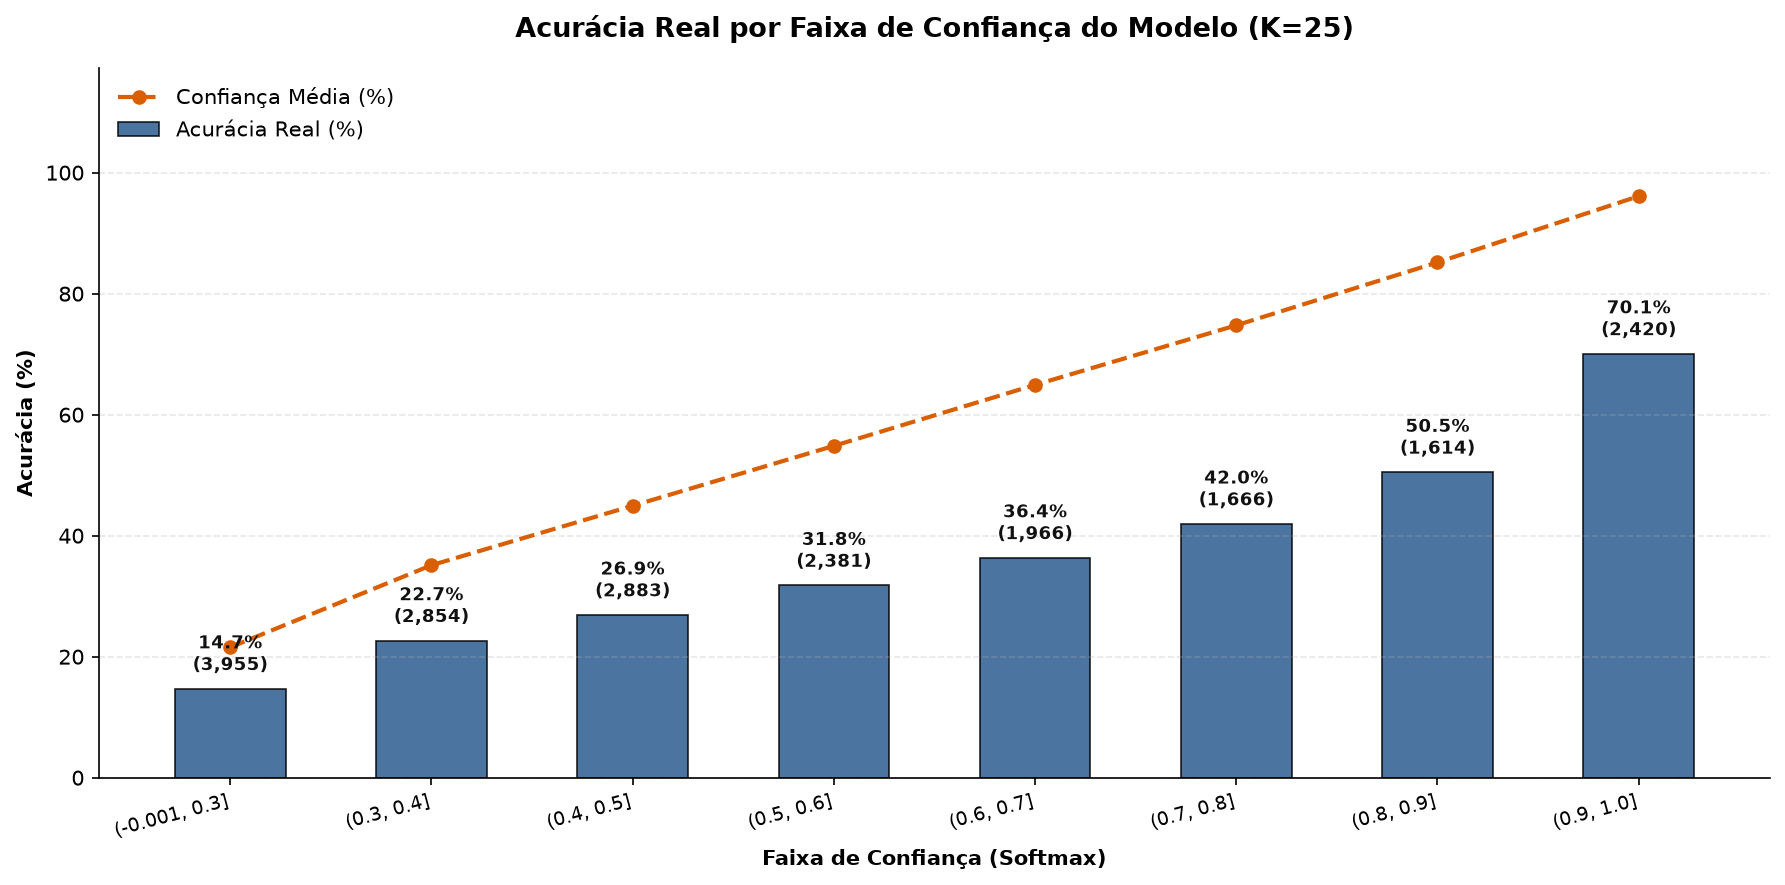

In [6]:
test_dataset = SparseDataset(X_test_25, y_te_enc)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

all_proba = []

with torch.no_grad():
    for inputs, _ in test_loader:
        
        inputs = inputs.to(device)
        
        outputs = model_25(inputs)
        
        proba = torch.softmax(outputs, dim=1)
        
        all_proba.append(
            proba.cpu().numpy()
        )

proba_test = np.vstack(all_proba)
confianca = proba_test.max(axis=1)
pred_proba = proba_test.argmax(axis=1)
acertou = pred_proba == y_te_enc

df_confianca = pd.DataFrame({
    "real": le.inverse_transform(y_te_enc),
    "predito": le.inverse_transform(pred_proba),
    "confianca": confianca,
    "acertou": acertou
})

bins = [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

df_confianca["faixa_confianca"] = pd.cut(
    df_confianca["confianca"],
    bins=bins,
    include_lowest=True
)

analise_confianca = (
    df_confianca
    .groupby("faixa_confianca", observed=False)
    .agg(
        quantidade=("acertou", "size"),
        acuracia=("acertou", "mean"),
        confianca_media=("confianca", "mean")
    )
)

analise_confianca["acuracia"] *= 100
df_plot = analise_confianca.reset_index().copy()
df_plot["faixa_str"] = df_plot["faixa_confianca"].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 6), dpi=150)

bars = ax1.bar(
    df_plot["faixa_str"],
    df_plot["acuracia"],
    color="#2b5c8f",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85,
    width=0.55,
    label="Acurácia Real (%)",
)

for bar, row in zip(bars, df_plot.itertuples()):
    height = bar.get_height()
    qtd = row.quantidade
    if qtd > 0:
        ax1.annotate(
            f"{height:.1f}%\n({qtd:,})",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
            color="#111111",
        )

conf_percent = df_plot["confianca_media"] * 100
ax1.plot(
    df_plot["faixa_str"],
    conf_percent,
    color="#d95f02",
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Confiança Média (%)",
)

ax1.set_title(
    "Acurácia Real por Faixa de Confiança do Modelo (K=25)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax1.set_xlabel("Faixa de Confiança (Softmax)", fontsize=10, fontweight="bold")
ax1.set_ylabel("Acurácia (%)", fontsize=10, fontweight="bold")

max_y = max(df_plot["acuracia"].max(), conf_percent.max())
ax1.set_ylim(0, max_y * 1.22)

plt.xticks(rotation=15, ha="right", fontsize=9)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax1.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()

In [ ]:
df_test = pd.read_parquet("../dados/processed/test.parquet")

df_analise_msg = df_test.copy()
df_analise_msg["membro_predito"] = df_confianca["predito"].values
df_analise_msg["confianca"] = df_confianca["confianca"].values
df_analise_msg["acertou"] = df_confianca["acertou"].values
df_analise_msg["faixa_confianca"] = df_confianca["faixa_confianca"].values

n_amostras = 20

amostras_lista = []
for faixa, group in df_analise_msg.groupby(
    "faixa_confianca", observed=False
):
    if len(group) > 0:
        qtd = min(len(group), n_amostras)
        sample_group = group.sample(n=qtd, random_state=42)
        amostras_lista.append(sample_group)

amostras_por_faixa = pd.concat(amostras_lista, axis=0)

colunas_exibicao = [
    "mensagem_embedding",
    "membro",
    "membro_predito",
    "confianca",
    "acertou",
]

for faixa, group in amostras_por_faixa.groupby(
    "faixa_confianca", observed=False
):
    print("\n" + "=" * 90)
    print(
        f" FAIXA DE CONFIANÇA: {faixa} | TOTAL EXIBIDO: {len(group)} MENSAGENS"
    )
    print("=" * 90)

    df_display = group[colunas_exibicao].copy()
    df_display["confianca"] = df_display["confianca"].apply(
        lambda x: f"{x*100:.2f}%"
    )

    display(df_display)


 FAIXA DE CONFIANÇA: (-0.001, 0.3] | TOTAL EXIBIDO: 20 MENSAGENS


,mensagem_embedding,membro,membro_predito,confianca,acertou
16850,ei,Caio,Você,20.90%,False
10511,@kau,Luiz,Luiz,27.28%,True
15412,se eu reprovar por falta,Cauã,Jão,29.66%,False
324,cereale,Jão,Ítalo,29.75%,False
12929,que isso,André,Caio,28.10%,False
12658,< >,Arthur,Arthur,16.70%,True
10496,caio,Arthur,Cauã,25.74%,False
19075,que merda,Luquete,Peter Lee,23.85%,False
1323,mano,Ítalo,Jão,14.37%,False
6368,parou aqui,Luquete,Guido,19.38%,False



 FAIXA DE CONFIANÇA: (0.3, 0.4] | TOTAL EXIBIDO: 20 MENSAGENS


,mensagem_embedding,membro,membro_predito,confianca,acertou
11037,cruzeiro tem 1 ponto a mais que o boca,Luiz,Luiz,39.43%,True
12037,só ler a foto,André,André,36.55%,True
5486,e que time vai jogar,Luquete,André,35.17%,False
12055,enfim,André,Yuras,37.03%,False
2641,só q o kg/selfservice,Jão,Você,38.29%,False
2751,nem pra dar pra artilheiros,Luquete,Luiz,39.32%,False
15888,sem fazer novos contatos,Luquete,Cauã,39.32%,False
7802,eu já,Luiz,Luiz,34.22%,True
16938,parece que ele tá com raiva de todo mundo,Luquete,Luquete,39.11%,True
18998,não perdeu tanta bola besta,Yuras,Luquete,33.19%,False



 FAIXA DE CONFIANÇA: (0.4, 0.5] | TOTAL EXIBIDO: 20 MENSAGENS


...

,mensagem_embedding,membro,membro_predito,confianca,acertou
11148,crl,Ítalo,Cauã,75.78%,False
11644,a maioria acha melhor dia 18,Guido,Luquete,76.34%,False
4711,várias pesquisas,Luquete,Yuras,71.13%,False
8518,acho que o renan santos tem uma coisa que eu s...,Caio,Luiz,70.07%,False
19052,mane,André,Jão,78.76%,False
1553,eu tô feliz mano,Guido,Guido,78.10%,True
11450,eu li agr,Guido,Ítalo,79.68%,False
808,600 de parcela +400 gasosa,Ítalo,Yuras,71.61%,False
4037,claude + duas api zinha,Ítalo,Você,74.05%,False
3402,kkkkkkkkkkkkkkkkk a bobeira,André,André,72.84%,True



 FAIXA DE CONFIANÇA: (0.8, 0.9] | TOTAL EXIBIDO: 20 MENSAGENS


,mensagem_embedding,membro,membro_predito,confianca,acertou
1878,@sr. quick açaí ainda tem paramount?,Luiz,Luiz,81.38%,True
15659,não pô calma aí,Luquete,Yuras,80.83%,False
13868,e agr monta lego,Cauã,Jão,82.75%,False
12404,mano pior q agr eu tô em duvida se vcs tão gas...,Guido,Guido,83.71%,True
9869,vi mermo,Luquete,Luquete,83.95%,True
18431,to puto o var nem olhou,Cauã,Cauã,81.28%,True
19412,bom dia sc,Peter Lee,Sr. Quick Açaí,89.43%,False
4654,mas falta o mbappe pra bet dar green,Luquete,Luquete,81.27%,True
11311,justamente porque a gente esqueceu,Peter Lee,Peter Lee,84.21%,True
3608,mas tbm é um mais basico,Guido,Arthur,87.42%,False



 FAIXA DE CONFIANÇA: (0.9, 1.0] | TOTAL EXIBIDO: 20 MENSAGENS


,mensagem_embedding,membro,membro_predito,confianca,acertou
3524,eles só n querem,Você,Você,98.27%,True
1848,eu fico mal que o arthur so deixa crente evang...,Luquete,Cauã,94.22%,False
13448,tem q mandar a tabela nutricional né,Jão,Jão,96.52%,True
8963,já tava pensando q ía ter q faltar pra ir no e...,Guido,Guido,100.00%,True
10817,que se elas não vierem vc vai ficar decepcionado,Peter Lee,Luiz,97.73%,False
7179,já tive oportunidade por menos de 100,Luquete,Luquete,94.50%,True
2300,igual gabriel jesus,Ítalo,Jão,98.56%,False
16949,😂😂,Luquete,Yuras,99.05%,False
12430,eu posto meu piru,Cauã,Cauã,93.30%,True
13862,kkkkkkkkkkkjkkkkkk,Você,Você,94.15%,True


/tmp/ipykernel_334478/3334486236.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


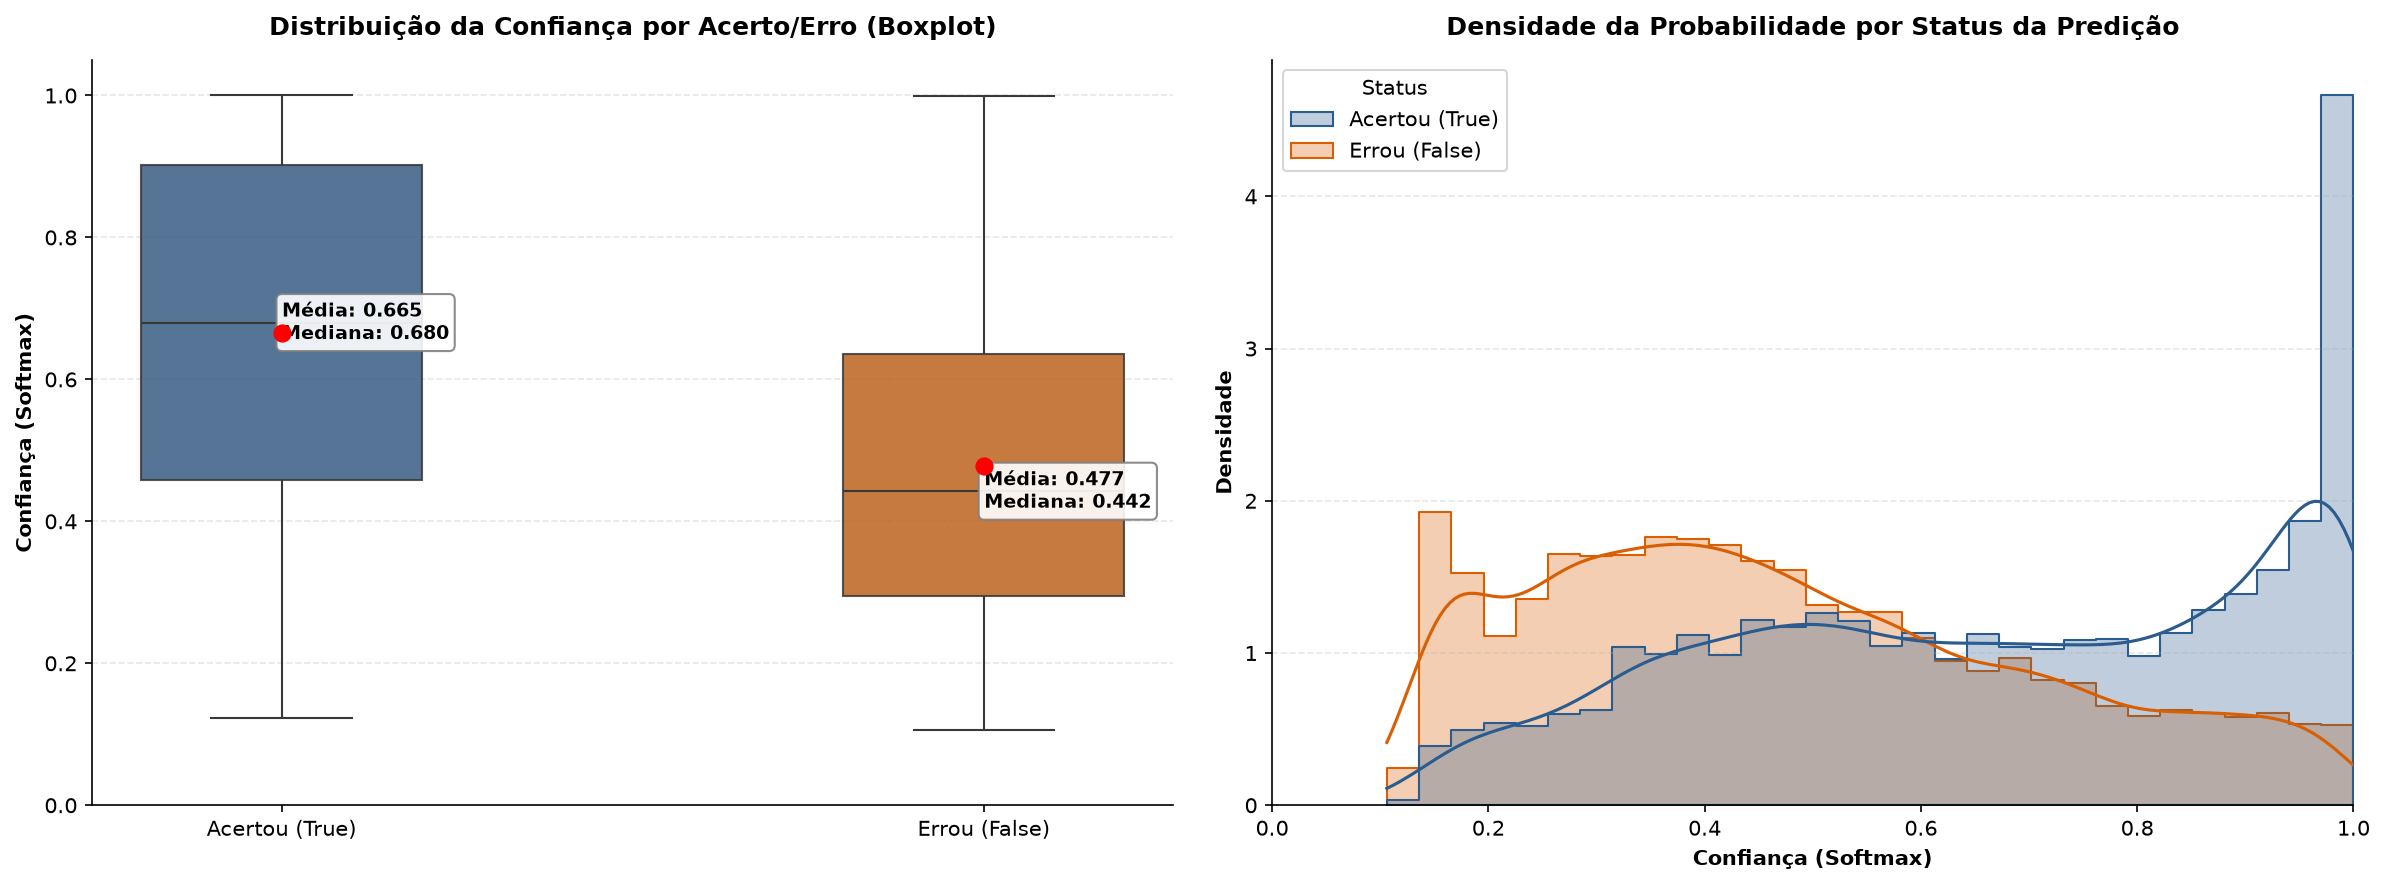

In [ ]:
import seaborn as sns

df_confianca["Status"] = df_confianca["acertou"].map(
    {True: "Acertou (True)", False: "Errou (False)"}
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

palette = {"Acertou (True)": "#2b5c8f", "Errou (False)": "#d95f02"}

sns.boxplot(
    data=df_confianca,
    x="Status",
    y="confianca",
    palette=palette,
    ax=ax1,
    width=0.4,
    fliersize=2,
    boxprops=dict(alpha=0.85),
)

# Adicionar pontos da média visualmente no boxplot
stats = df_confianca.groupby("Status")["confianca"].agg(["mean", "median"])
for i, (status, row) in enumerate(stats.iterrows()):
    ax1.scatter(
        i,
        row["mean"],
        color="red",
        s=60,
        zorder=5,
        label="Média" if i == 0 else "",
    )
    ax1.annotate(
        f"Média: {row['mean']:.3f}\nMediana: {row['median']:.3f}",
        xy=(i, row["median"]),
        xytext=(0.28, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9
        ),
    )

ax1.set_title(
    "Distribuição da Confiança por Acerto/Erro (Boxplot)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("")
ax1.set_ylabel("Confiança (Softmax)", fontsize=10, fontweight="bold")
ax1.set_ylim(0, 1.05)

sns.histplot(
    data=df_confianca,
    x="confianca",
    hue="Status",
    element="step",
    stat="density",
    common_norm=False,
    bins=30,
    palette=palette,
    kde=True,
    ax=ax2,
    alpha=0.3,
)

ax2.set_title(
    "Densidade da Probabilidade por Status da Predição",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax2.set_xlabel("Confiança (Softmax)", fontsize=10, fontweight="bold")
ax2.set_ylabel("Densidade", fontsize=10, fontweight="bold")
ax2.set_xlim(0, 1)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

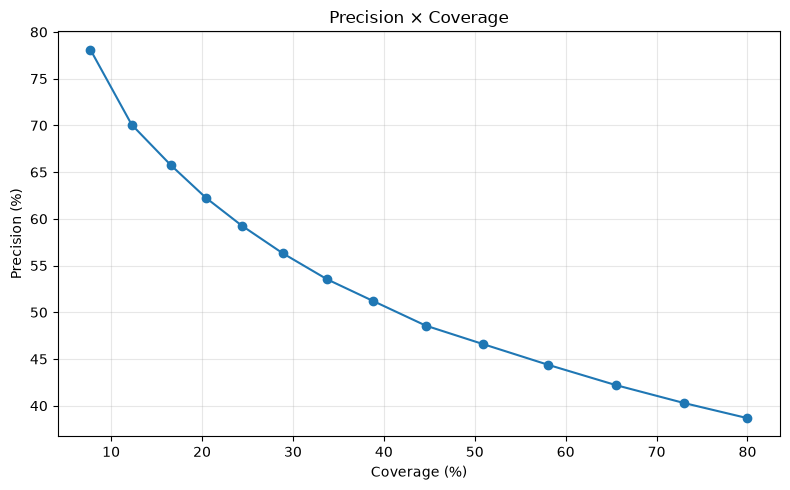

In [8]:
thresholds = np.arange(0.30, 1.00, 0.05)

resultados_threshold = []

for threshold in thresholds:
    
    selecionados = confianca >= threshold
    
    coverage = selecionados.mean()
    
    if selecionados.sum() > 0:
        precision = acertou[selecionados].mean()
    else:
        precision = np.nan
    
    resultados_threshold.append({
        "threshold": threshold,
        "precision": precision,
        "coverage": coverage,
        "mensagens": selecionados.sum()
    })

df_threshold = pd.DataFrame(resultados_threshold)

df_threshold["precision"] *= 100
df_threshold["coverage"] *= 100

plt.figure(figsize=(8, 5))

plt.plot(
    df_threshold["coverage"],
    df_threshold["precision"],
    marker="o"
)

plt.xlabel("Coverage (%)")
plt.ylabel("Precision (%)")
plt.title("Precision × Coverage")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

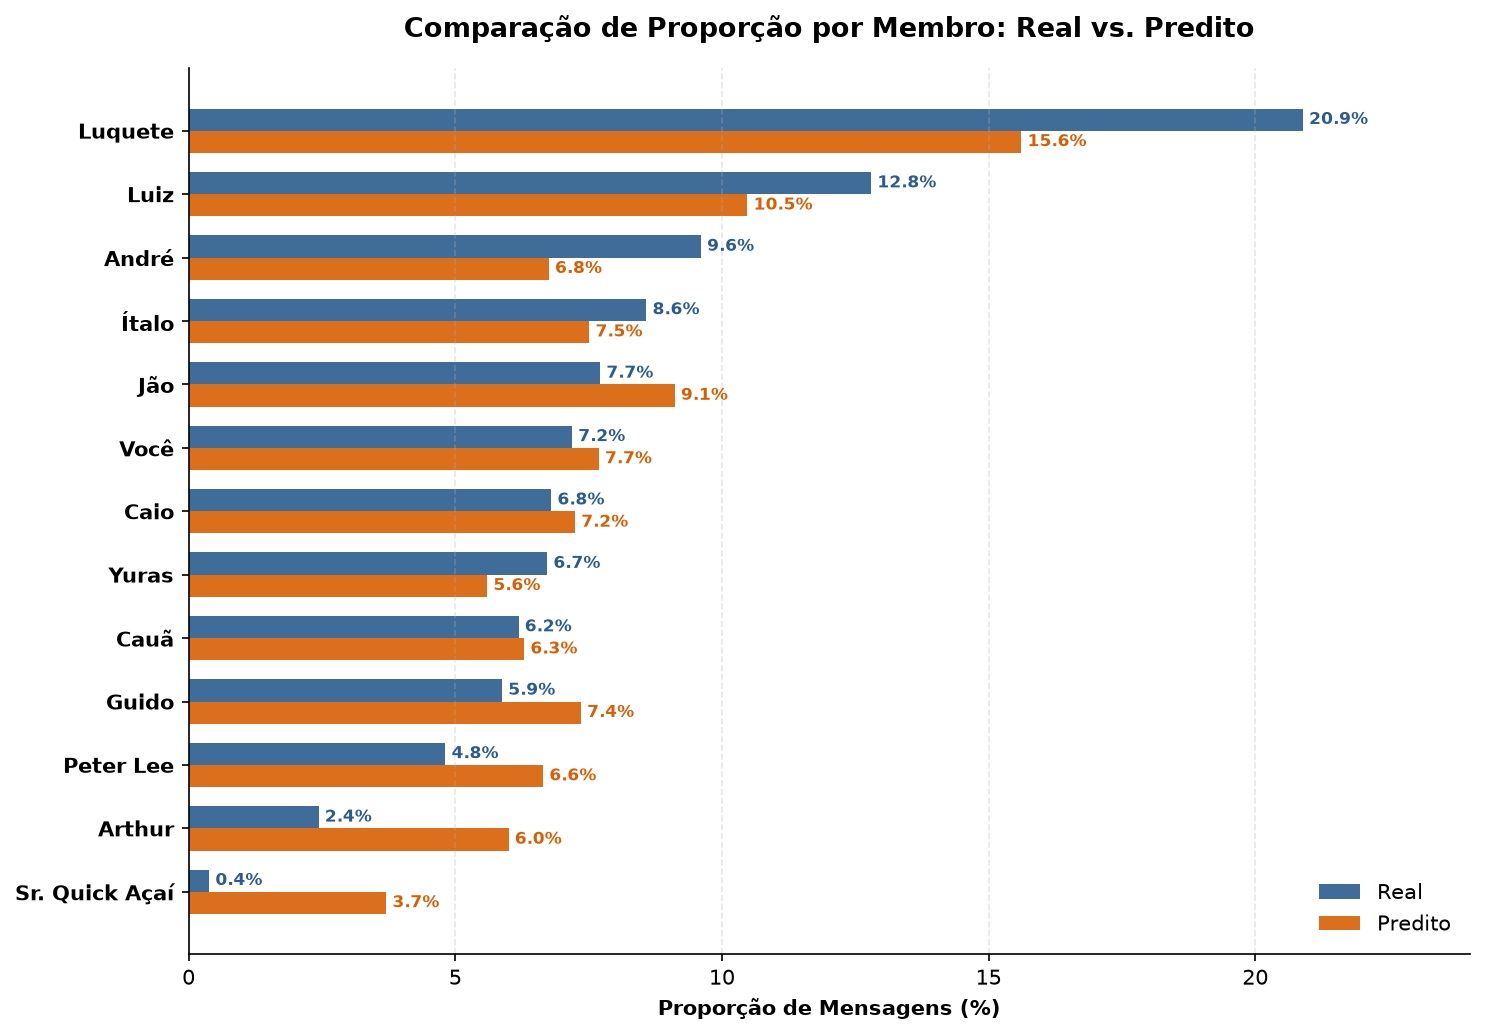

In [9]:
real_dist = (
    pd.Series(le.inverse_transform(y_te_enc))
    .value_counts(normalize=True)
    .rename("real")
)

pred_dist = (
    pd.Series(le.inverse_transform(pred_proba))
    .value_counts(normalize=True)
    .rename("predito")
)

comparacao_dist = pd.concat(
    [real_dist, pred_dist],
    axis=1
).fillna(0)

comparacao_dist["diferenca"] = (
    comparacao_dist["predito"] -
    comparacao_dist["real"]
)

comparacao_dist.sort_values(
    "diferenca",
    ascending=False
)
df_plot = comparacao_dist.sort_values("real", ascending=True)

y = np.arange(len(df_plot))
height = 0.35  

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

rects1 = ax.barh(
    y + height / 2,
    df_plot["real"] * 100,
    height,
    label="Real",
    color="#2b5c8f",
    alpha=0.9,
)
rects2 = ax.barh(
    y - height / 2,
    df_plot["predito"] * 100,
    height,
    label="Predito",
    color="#d95f02",
    alpha=0.9,
)

for rect in rects1:
    width = rect.get_width()
    ax.annotate(
        f"{width:.1f}%",
        xy=(width, rect.get_y() + rect.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="#2b5c8f",
        fontweight="bold",
    )

for rect in rects2:
    width = rect.get_width()
    ax.annotate(
        f"{width:.1f}%",
        xy=(width, rect.get_y() + rect.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="#d95f02",
        fontweight="bold",
    )

ax.set_title(
    "Comparação de Proporção por Membro: Real vs. Predito",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Proporção de Mensagens (%)", fontsize=10, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(df_plot.index, fontsize=10, fontweight="bold")

max_val = max(df_plot["real"].max(), df_plot["predito"].max()) * 100
ax.set_xlim(0, max_val * 1.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

ax.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=10,
)

plt.tight_layout()
plt.show()


# Escolha do Threshold na Perspectiva da Regra de Negócio

Partindo da premissa de que o bot é o Fiscal Absoluto de Estilo (onde o modelo dita a "verdade factual do estilo" e valida se o membro é autêntico ou um impostor), a escolha do threshold não serve para evitar erros do modelo, mas sim para definir a convicção do bot e controlar o ritmo do grupo.

## O Volume Real de Intervenções (Sem Spam)

Olhando para a distribuição dos seus dados de teste (~19.7k mensagens):   

 - Intervalo $P \ge 0.80$ (Faixas 0.8-0.9 e 0.9-1.0): Soma 4.034 mensagens (~20.4% de todo o chat).   
 - Intervalo $P \ge 0.70$ (Faixas 0.7-0.8, 0.8-0.9 e 0.9-1.0): Soma 5.700 mensagens (~28.9% de todo o chat).   

**Conclusão de produto:** Disparar em 20% a 30% de todas as mensagens do WhatsApp vai poluir o grupo rapidamente (o bot falaria a cada 3 ou 4 mensagens). Por isso, a escolha do threshold deve ser combinada com uma regra de amostragem (sorteio).


| Threshold                    |   Convicção do Bot | % Mensagens Elegíveis | % Acurácia do Modelo | Comportamento Recreativo do Bot |
| ---------------------------- | -----------------  | ----------------------| -------------------- | -------------------------------:
| 0.70                |     Média-Alta | ~28.9% | ~42% a 70% | O bot é mais "implicante" e entra em conversas onde o tom é levemente ambíguo. |
| 0.80 ⭐           |     Alta | ~20.4% | 50.5% a 70.1% | O ponto de equilíbrio perfeito. O bot fala com propriedade de autoridade e a piada encaixa muito bem. |
| 0.90             |    Certeza Absoluta | ~12.2% | 70.1% | O bot vira uma "entidade rara". Ele só aparece quando a assinatura estilística é inquestionável. |


## A Regra de Negócio Completa (Arquitetura de Disparo)

Para o bot funcionar na prática sem virar spam, o fluxo ideal combina 3 travas em sequência:

### Passo 1: Sanitização da Mensagem

 - Descartar mensagens vazias, mídias não baixadas (< >), hashes/links (/4aaqsk...) ou frases com menos de 2 palavras.

### Passo 2: O Crivo da Convicção ($P \ge 0.80$)

 - Calcular as probabilidades do model_25.
 - Se a maior probabilidade $P_{\text{max}} < 0.80$, o bot ignora e permanece calado.
  
### Passo 3: Trava de Cadência (Sorteio + Cooldown)

 - Mesmo que $P_{\text{max}} \ge 0.80$, aplicar uma chance de resposta (ex: 20% a 30% de probabilidade de o bot falar).
 - Adicionar um cooldown simples por usuário (ex: no máximo 1 intervenção por pessoa a cada 1 hora).

## Mapeamento de Eventos para a LLM Generativa

Quando a regra bater todas as travas, o bot define o tipo_evento e envia o contexto estruturado para a LLM gerar a piada:

### Evento A: IMPOSTOR_DETECTADO ($A_{\text{predito}} \neq A_{\text{real}}$ e $P \ge 0.80$)

 - Conceito: O autor mandou a mensagem, mas usou o estilo/gíria de outro participante.

 - Payload para a LLM:

 ```{json}
    {
    "evento": "IMPOSTOR_DETECTADO",
    "autor_real": "Cauã",
    "autor_estilo": "Luquete",
    "confianca": "94.2%",
    "mensagem": "eu fico mal que o arthur so deixa crente evang..."
    }
 ```

 - Instrução no Prompt: Acusar o autor_real de estar sendo possuído por autor_estilo, de usar conta fake ou de ser um clone malfeito.

### Evento B: AUTENTICIDADE_CONFIRMADA ($A_{\text{predito}} == A_{\text{real}}$ e $P \ge 0.80$

 - Conceito: O autor escreveu com a assinatura estilística exata dele.

 - Payload para a LLM:

 ```{json}
    {
    "evento": "AUTENTICIDADE_CONFIRMADA",
    "autor_real": "Guido",
    "autor_estilo": "Guido",
    "confianca": "100.0%",
    "mensagem": "já tava pensando q ía ter q faltar pra ir no e..."
    }
 ```

 - Instrução no Prompt: Emitir um "Atestado de Autenticidade" burocrático e irônico, parabenizando o autor_real por não estar se passando por ninguém hoje.